Transactions: 112
Columns: ['tx_hash', 'from', 'to', 'value', 'block_number']
Nodes: 156
Edges: 112


/tmp/ipykernel_37615/3144116099.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


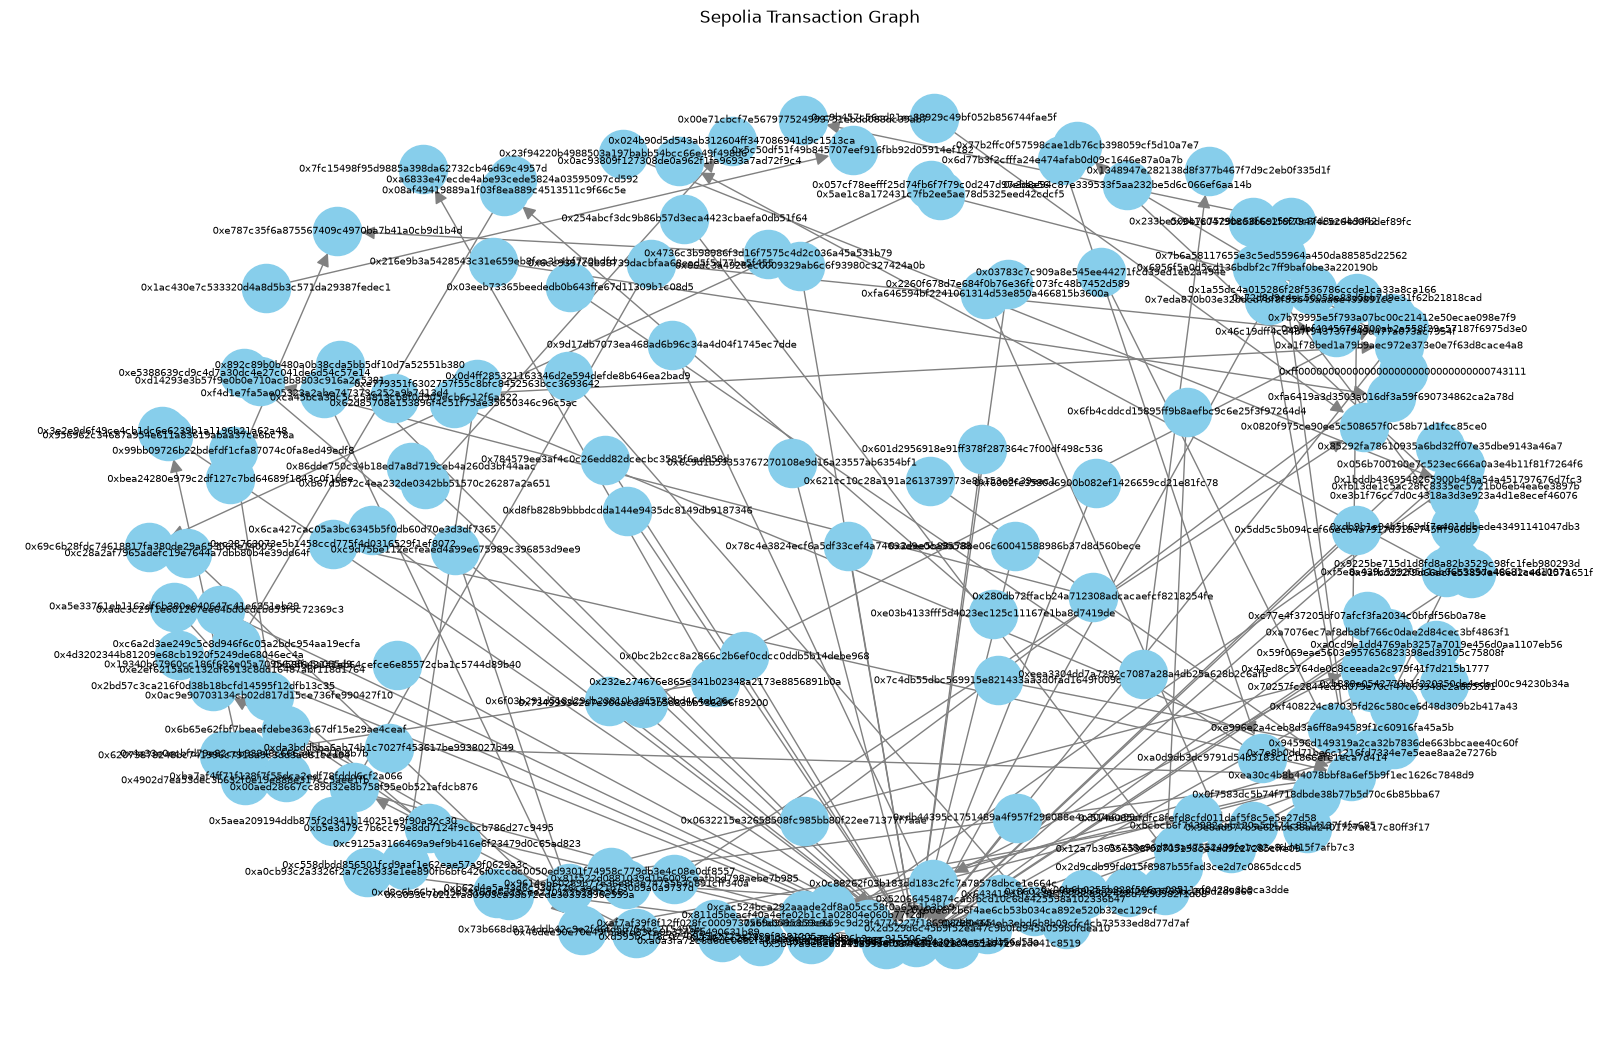

In [1]:
    import pandas as pd
    import networkx as nx
    import matplotlib.pyplot as plt
    
    
    # -------------------------
    # 1. Load transaction data
    # -------------------------
    
    df = pd.read_csv("../../data/sepolia_transactions.csv")
    
    print("Transactions:", len(df))
    print("Columns:", df.columns.tolist())
    
    
    # -------------------------
    # 2. Create graph
    # -------------------------
    
    G = nx.DiGraph()
    
    for _, tx in df.iterrows():
    
        sender = tx["from"]
        receiver = tx["to"]
    
        # Skip transactions without a receiver
        if pd.isna(receiver) or receiver == "":
            continue
    
        G.add_edge(
            sender,
            receiver,
            tx_hash=tx["tx_hash"],
            value=tx["value"],
            block_number=tx["block_number"]
        )
    
    
    # -------------------------
    # 3. Print graph information
    # -------------------------
    
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    
    
    # -------------------------
    # 4. Draw graph
    # -------------------------
    
    plt.figure(figsize=(16, 10))
    
    pos = nx.spring_layout(
        G,
        k=0.8,
        iterations=50,
        seed=42
    )
    
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1200,
        node_color="skyblue",
        arrows=True,
        arrowsize=20,
        font_size=7,
        edge_color="gray"
    )
    
    plt.title("Sepolia Transaction Graph")
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_37615/1109121875.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


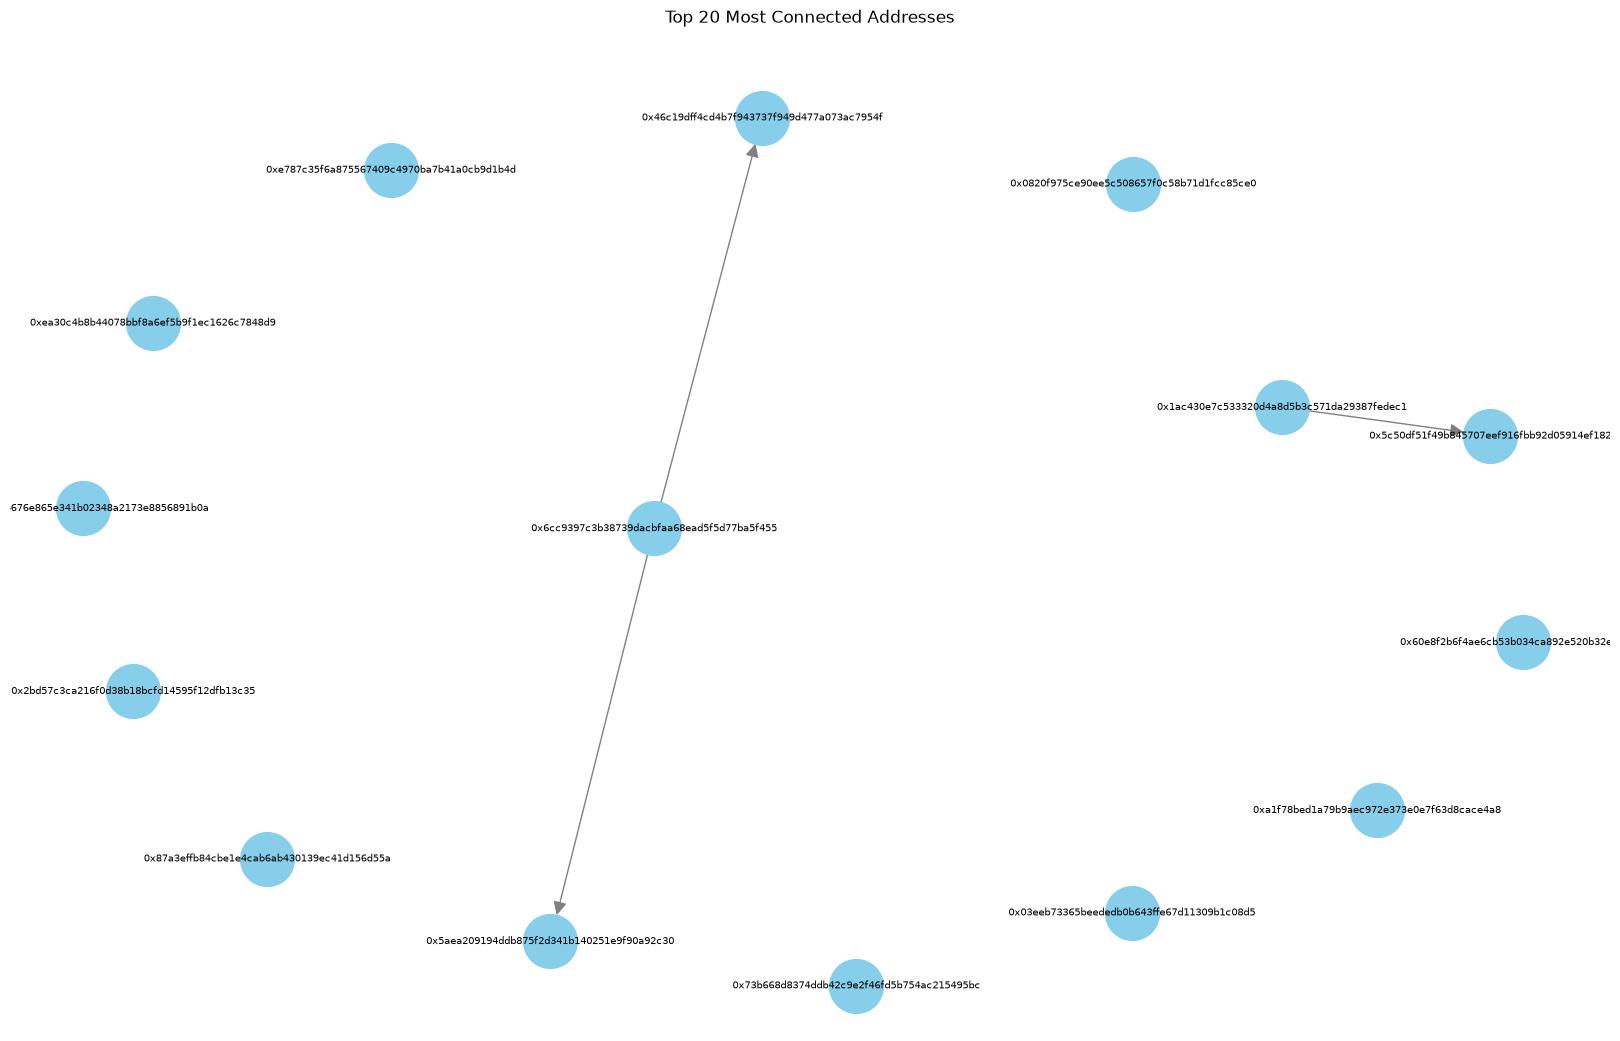

In [6]:
# Find the 15 most connected addresses
degree = dict(G.degree())

top_nodes = sorted(
    degree,
    key=degree.get,
    reverse=True
)[:15]

H = G.subgraph(top_nodes).copy()


plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    H,
    k=1.2,
    iterations=100,
    seed=42
)

nx.draw(
    H,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="skyblue",
    arrows=True,
    arrowsize=20,
    font_size=7,
    edge_color="gray"
)

plt.title("Top 20 Most Connected Addresses")

plt.tight_layout()
plt.show()

In [42]:
def get_transactions(wallet):
    wallet = wallet.lower()

    txs = df[
        (df["from"].str.lower() == wallet) |
        (df["to"].str.lower() == wallet)
    ]

    return txs.to_dict("records")

In [43]:
def get_outgoing_transactions(wallet):

    wallet = wallet.lower()

    txs = df[
        df["from"].str.lower() == wallet
    ]

    return txs.to_dict("records")


def trace_wallet(start_address, max_hops=3):

    visited = set()
    graph = []

    current_wallets = [start_address.lower()]

    for hop in range(1, max_hops + 1):

        print(f"\n========== HOP {hop} ==========")

        next_wallets = []

        for wallet in current_wallets:

            if wallet in visited:
                continue

            visited.add(wallet)

            transactions = get_outgoing_transactions(wallet)

            print(
                f"Wallet: {wallet}"
            )

            print(
                f"Outgoing transactions: {len(transactions)}"
            )

            for tx in transactions:

                sender = tx["from"].lower()
                receiver = tx["to"].lower()

                # Save transaction
                graph.append({
                    "from": sender,
                    "to": receiver,
                    "tx_hash": tx["tx_hash"],
                    "value": tx["value"],
                    "block_number": tx["block_number"],
                    "hop": hop
                })

                # Follow the money
                if receiver not in visited:
                    next_wallets.append(receiver)

        # Remove duplicates
        current_wallets = list(set(next_wallets))

        if not current_wallets:
            print("No more wallets to trace.")
            break

    return graph

In [47]:
transaction = trace_wallet(
    "	0x6663674ac201faaf5435d7a9a49592941549975c",
    max_hops=3
)


========== HOP 1 ==========
Wallet: 	0x6663674ac201faaf5435d7a9a49592941549975c
Outgoing transactions: 0
No more wallets to trace.



========== HOP 1 ==========
Wallet: 0xd77db750b317d2ed02d8dcb6280fc2833a71e462
Outgoing transactions: 0
No more wallets to trace.
Nodes: 0
Edges: 0

========== TRANSACTIONS ==========

========== CYCLES ==========
No cycles found


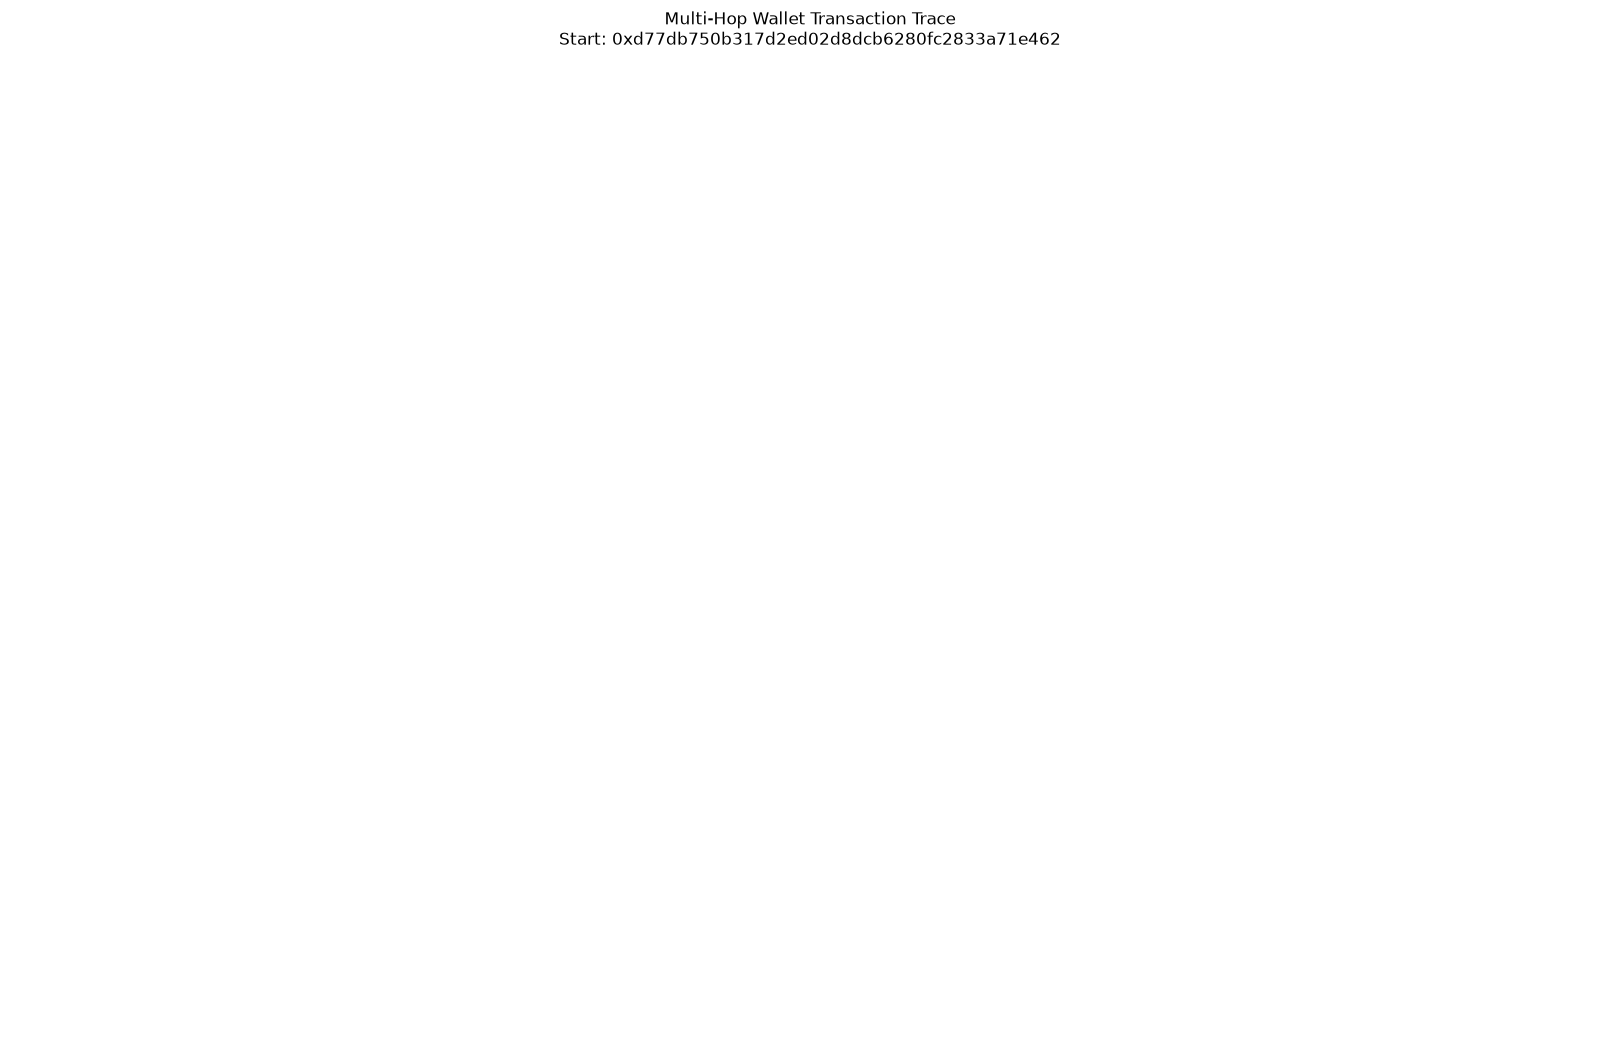

In [45]:
start_address = "0xd77db750b317d2ed02d8dcb6280fc2833a71e462"

transactions = trace_wallet(
    start_address,
    max_hops=3
)

hopGraph = nx.DiGraph()

for tx in transactions:

    hopGraph.add_edge(
        tx["from"],
        tx["to"],
        tx_hash=tx["tx_hash"],
        value=tx["value"],
        block_number=tx["block_number"],
        hop=tx["hop"]
    )

print("Nodes:", hopGraph.number_of_nodes())
print("Edges:", hopGraph.number_of_edges())

print("\n========== TRANSACTIONS ==========")

for tx in transactions:

    print(
        f'HOP {tx["hop"]}: '
        f'{tx["from"]} → {tx["to"]}'
    )


# -----------------------------------------
# Cycle detection
# -----------------------------------------

cycles = list(nx.simple_cycles(hopGraph))

print("\n========== CYCLES ==========")

if cycles:

    for cycle in cycles:
        print("Cycle:", " → ".join(cycle))

else:

    print("No cycles found")


# -----------------------------------------
# Draw graph
# -----------------------------------------

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    hopGraph,
    k=1.5,
    iterations=100,
    seed=42
)

nx.draw(
    hopGraph,
    pos,
    with_labels=True,
    node_size=1800,
    node_color="skyblue",
    arrows=True,
    arrowsize=25,
    font_size=7
)

plt.title(
    f"Multi-Hop Wallet Transaction Trace\n"
    f"Start: {start_address}"
)

plt.show()


========== HOP 1 ==========
Wallet: 0x03eeb73365beededb0b643ffe67d11309b1c08d5
Outgoing transactions: 1

========== HOP 2 ==========
Wallet: 0x0f7583dc5b74f718dbde38b77b5d70c6b85bba67
Outgoing transactions: 0
No more wallets to trace.
Nodes: 2
Edges: 1
HOP 1: 0x03eeb733... → 0x0f7583dc...


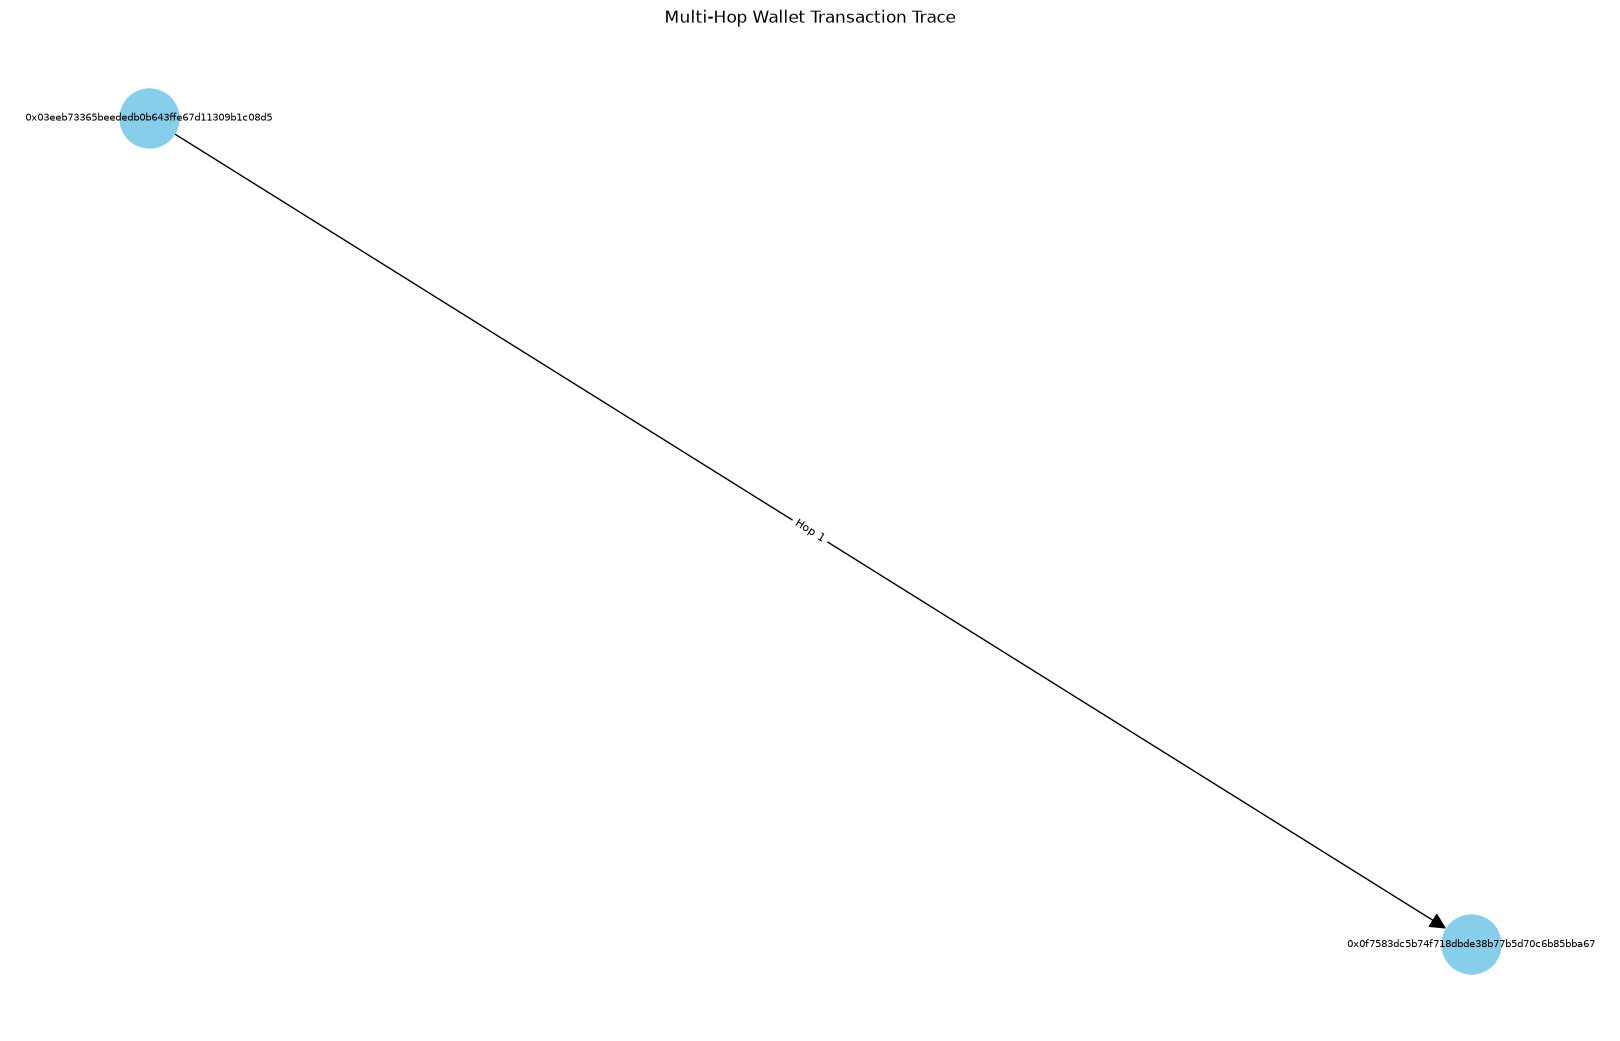

In [40]:
start_address = "0x03eeb73365beededb0b643ffe67d11309b1c08d5"

transactions = trace_wallet(
    start_address,
    max_hops=3
)

hopGraph = nx.DiGraph()

for tx in transactions:

    hopGraph.add_edge(
        tx["from"],
        tx["to"],
        tx_hash=tx["tx_hash"],
        value=tx["value"],
        block_number=tx["block_number"],
        hop=tx["hop"]
    )

print("Nodes:", hopGraph.number_of_nodes())
print("Edges:", hopGraph.number_of_edges())

for tx in transactions:
    print(
        f'HOP {tx["hop"]}: '
        f'{tx["from"][:10]}... → {tx["to"][:10]}...'
    )

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    hopGraph,
    k=2,
    iterations=100,
    seed=42
)

nx.draw(
    hopGraph,
    pos,
    with_labels=True,
    node_size=1800,
    node_color="skyblue",
    arrows=True,
    arrowsize=25,
    font_size=7
)

# Draw hop labels on edges
edge_labels = {
    (u, v): f'Hop {data["hop"]}'
    for u, v, data in hopGraph.edges(data=True)
}

nx.draw_networkx_edge_labels(
    hopGraph,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Multi-Hop Wallet Transaction Trace")

plt.show()